# Analyse Statistique - Reseaux d'Acteurs IA

Ce notebook fournit un tableau de bord statistique de la base entreprises IA.

## Objectif

Mesurer la qualite de la base (completude, validation) et decrire sa structure (pays, annee, secteurs).

## Finalites

- Mesurer la couverture des donnees (completude et validation).
- Decrire la structure du corpus (pays, annee, secteur).
- Produire des exports reutilisables pour le pilotage data.

## Convention de lecture

Chaque section suit le schema: **Objectif -> Entrees -> Traitement -> Sorties**.

## Principe de construction de la base

La base suit une logique iterative semi-manuelle: amorcage multi-sources, enrichissement, deduplication, verification croisee, puis nouvelle iteration.

## Schema de la boucle d'enrichissement

1. Amorcage multi-sources.
2. Enrichissement en boule de neige.
3. Deduplication et normalisation.
4. Recherche ciblee sur les angles morts.
5. Validation humaine et reinjection en base.

```mermaid
flowchart LR
    A[Amorcage] --> B[Enrichissement]
    B --> C[Deduplication]
    C --> D[Recherche ciblee]
    D --> E[Validation]
    E --> F[Mise a jour base]
    F --> B
```

## 1. Configuration et chargement des donnees

**Objectif**: initialiser l'environnement, charger les entreprises depuis `database.db` et preparer les colonnes analytiques.

**Entrees**: table `enterprises` en base SQLite locale.
**Traitement**: parsing robuste de `capitalization`, normalisation de `is_validated`.
**Sortie**: DataFrame `df` pret pour l'analyse.

In [32]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Configuration des graphiques
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path().resolve().parent
DB_PATH = ROOT / "database.db"

print("✓ Bibliothèques importées")
print(f"✓ Base SQLite: {DB_PATH}")

✓ Bibliothèques importées
✓ Base SQLite: C:\Users\33623\Documents\___Projets\AI\Reseaux d'acteurs\database.db


In [33]:
# Charger les données depuis la base SQLite locale
def parse_capitalization_millions(value):
    """Convertit la capitalisation format FR (ex: '1 234,56') en float (millions)."""
    if value is None:
        return 0.0
    text = str(value).strip()
    if text == '' or text == '0':
        return 0.0
    text = text.replace(' ', '').replace('\u202f', '').replace('\u00a0', '').replace(',', '.')
    try:
        return float(text)
    except ValueError:
        return 0.0

try:
    if not DB_PATH.exists():
        raise FileNotFoundError(f"Base introuvable: {DB_PATH}")

    query = """
    SELECT
        id,
        name,
        sector,
        country,
        founded_year,
        capitalization,
        is_validated,
        description,
        website,
        headquarter_city,
        main_investors,
        funds_raised,
        created_at,
        updated_at
    FROM enterprises
    """

    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(query, con)

    # Normalise le schema pour eviter les KeyError si des colonnes manquent.
    expected_defaults = {
        'id': None,
        'name': None,
        'sector': None,
        'country': None,
        'founded_year': None,
        'capitalization': '0',
        'is_validated': 0,
        'description': None,
        'website': None,
        'headquarter_city': None,
        'main_investors': None,
        'funds_raised': None,
        'created_at': None,
        'updated_at': None,
    }
    for col, default in expected_defaults.items():
        if col not in df.columns:
            df[col] = default

    df['capitalization'] = df['capitalization'].fillna('0').astype(str)
    df['capitalization_millions'] = df['capitalization'].apply(parse_capitalization_millions)
    df['is_validated'] = pd.to_numeric(df['is_validated'], errors='coerce').fillna(0).astype(int)

    non_validees = (df['is_validated'] == 0).sum() if not df.empty else 0
    partiellement_validees = (df['is_validated'] == 1).sum() if not df.empty else 0
    validees = (df['is_validated'] == 2).sum() if not df.empty else 0

    print(f"✓ {len(df)} entreprises chargées depuis la base")
    print(
        f"Validation: non={non_validees}, "
        f"partiel={partiellement_validees}, valide={validees}"
    )
    print(f"\nColonnes: {df.columns.tolist()}")
except Exception as e:
    print(f"✗ Erreur: {e}")
    df = pd.DataFrame()

✓ 1846 entreprises chargées depuis la base
Validation: non=0, partiel=123, valide=111

Colonnes: ['id', 'name', 'sector', 'country', 'founded_year', 'capitalization', 'is_validated', 'description', 'website', 'headquarter_city', 'main_investors', 'funds_raised', 'created_at', 'updated_at', 'capitalization_millions']


In [34]:
# Afficher un aperçu des données
print("📊 Aperçu des données:\n")
preview_cols = [
    'id', 'name', 'sector', 'country', 'founded_year',
    'capitalization', 'capitalization_millions', 'is_validated'
]
preview_cols = [c for c in preview_cols if c in df.columns]
print(df[preview_cols].head(10))
print(f"\nShape: {df.shape}")
print(f"\nTypes de données:\n{df.dtypes}")

📊 Aperçu des données:

   id                 name                                           sector  \
0   1             Cerebras                                    Hardware, GPU   
1   2            Anthropic                                    Hardware, ICT   
2   3           Mistral AI                                    AI model, ICT   
3   4               Google                                              ICT   
4   5            Microsoft  Cloud Provider, AI model, Professional Services   
5   7         Hugging Face                                    Hardware, ICT   
6   8                DeepL                                              ICT   
7   9  Amazon Web Services                                    Hardware, ICT   
8  10               GitHub                  AI model, Professional Services   
9  11        Perplexity AI                                              ICT   

         country  founded_year capitalization  capitalization_millions  \
0  United States        2016.0   

**Lecture rapide**: cette etape valide la qualite du chargement (colonnes, types, volume) avant tout calcul statistique.

## 2. Statistiques generales et completude

**Objectif**: mesurer le taux de renseignement de chaque champ pour prioriser l'enrichissement.

**Sortie**: tableau de completude et visualisation des colonnes les plus/moins couvertes.

📈 Taux de Complétude des Champs:

id                       : 1846/1846 (100.0%)
name                     : 1846/1846 (100.0%)
sector                   : 1558/1846 ( 84.4%)
country                  : 1686/1846 ( 91.3%)
founded_year             : 301/1846 ( 16.3%)
capitalization           : 242/1846 ( 13.1%)
is_validated             : 1846/1846 (100.0%)
description              : 1568/1846 ( 84.9%)
website                  : 1513/1846 ( 82.0%)
headquarter_city         : 268/1846 ( 14.5%)
main_investors           : 142/1846 (  7.7%)
funds_raised             : 131/1846 (  7.1%)
created_at               : 1846/1846 (100.0%)
updated_at               : 1846/1846 (100.0%)
capitalization_millions  : 1846/1846 (100.0%)


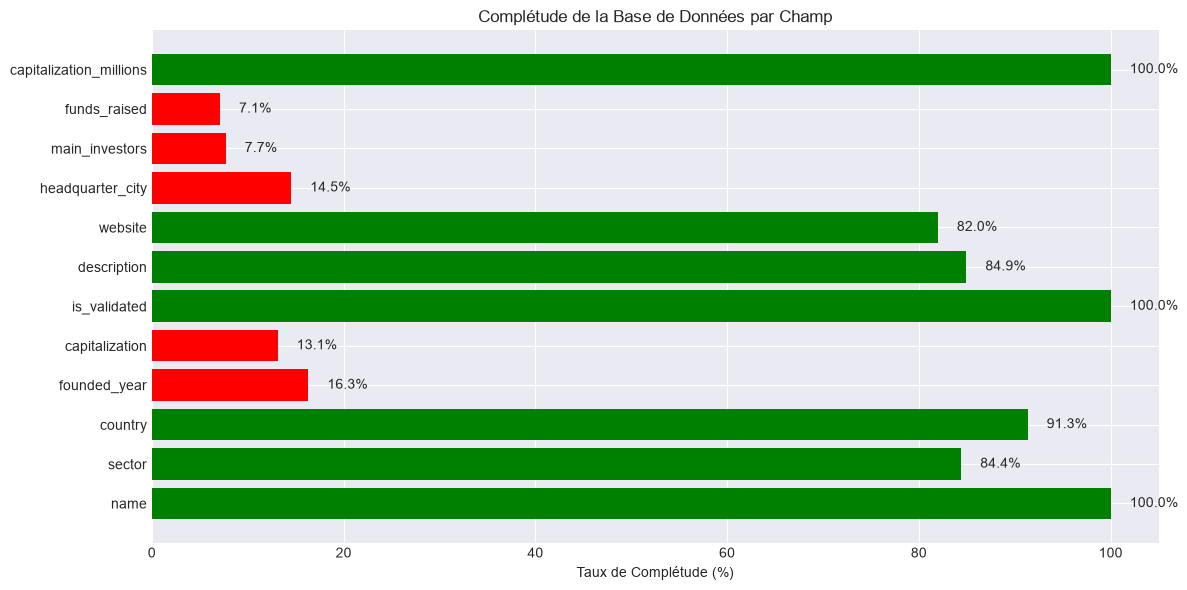

In [35]:
# Statistiques de complétude
print("📈 Taux de Complétude des Champs:\n")

def filled_series(series):
    return series.notna() & (series.astype(str).str.strip() != '')

completeness = {}
for col in df.columns:
    if col == 'capitalization':
        # Règle métier: '0' = pas d'information de capitalisation
        non_null = (df['capitalization_millions'] > 0).sum() if 'capitalization_millions' in df.columns else 0
    else:
        non_null = filled_series(df[col]).sum()
    pct = (non_null / len(df)) * 100 if len(df) else 0
    completeness[col] = pct
    print(f"{col:25s}: {non_null:3d}/{len(df)} ({pct:5.1f}%)")

# Visualiser la complétude
fig, ax = plt.subplots(figsize=(12, 6))
cols = [c for c in completeness.keys() if c not in ['id', 'created_at', 'updated_at']]
values = [completeness[c] for c in cols]

bars = ax.barh(cols, values, color=['green' if v >= 80 else 'orange' if v >= 50 else 'red' for v in values])
ax.set_xlabel('Taux de Complétude (%)')
ax.set_title('Complétude de la Base de Données par Champ')
ax.set_xlim(0, 105)

# Ajouter les pourcentages sur les barres
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 2, i, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

**Lecture rapide**: les champs faibles en completude deviennent des cibles prioritaires de collecte.

## 3. Repartition par pays

**Objectif**: mesurer la concentration geographique des entreprises du corpus.

**Sorties**: classement des pays, barres top 10 et camembert de distribution.


🌍 Répartition par Pays (36 pays):

country
Germany                 929
Sweden                  213
Netherlands             174
United States           169
Unknown                 160
United Kingdom           56
France                   41
China                    34
Canada                    9
Israel                    7
India                     6
Spain                     6
South Korea               5
Singapore                 4
Austria                   4
Switzerland               3
United Arab Emirates      3
Japan                     2
Italy                     2
Belgium                   2
Finland                   2
Hong Kong                 1
Saudi Arabia              1
Portugal                  1
Ukraine                   1
Australia                 1
Brazil                    1
Taiwan                    1
Poland                    1
Norway                    1
Pakistan                  1
Turkey                    1
Indonesia                 1
Corea                     1
Gree

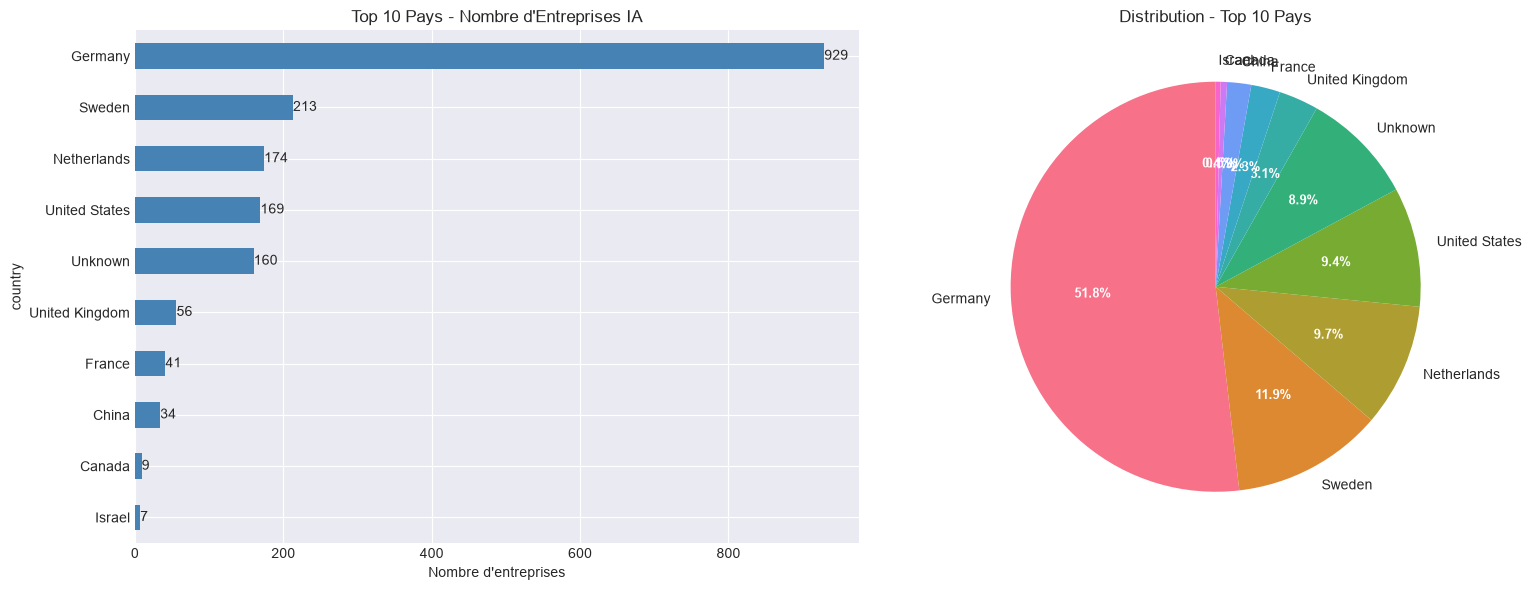

In [36]:
# Analyse par pays
if df is None or df.empty or 'country' not in df.columns:
    print("⚠️ Aucune donnée pays disponible (dataset vide ou colonne 'country' absente).")
else:
    country_counts = (
        df['country']
        .fillna('Unknown')
        .astype(str)
        .str.strip()
        .replace('', 'Unknown')
        .value_counts()
    )

    print(f"\n🌍 Répartition par Pays ({len(country_counts)} pays):\n")
    print(country_counts)

    # Top 10 pays
    top_countries = country_counts.head(10)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique 1: Top 10 pays (barre horizontale)
    top_countries.plot(kind='barh', ax=ax1, color='steelblue')
    ax1.set_xlabel('Nombre d\'entreprises')
    ax1.set_title('Top 10 Pays - Nombre d\'Entreprises IA')
    ax1.invert_yaxis()

    # Ajouter les chiffres
    for i, v in enumerate(top_countries.values):
        ax1.text(v + 0.1, i, str(v), va='center')

    # Graphique 2: Camembert
    colors = sns.color_palette('husl', len(top_countries))
    wedges, texts, autotexts = ax2.pie(top_countries.values, labels=top_countries.index, autopct='%1.1f%%',
                                        colors=colors, startangle=90)
    ax2.set_title('Distribution - Top 10 Pays')

    # Améliorer la lisibilité du texte
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)

    plt.tight_layout()
    plt.show()

**Lecture rapide**: cette vue met en evidence les poles nationaux dominants et les risques de biais geographique.

## 4. Repartition par annee de fondation

**Objectif**: analyser la dynamique temporelle de creation des entreprises IA.

**Sorties**: stats de periode, distribution annuelle et courbe de tendance.

In [46]:
# Nettoyer et analyser les annees
year_counts = pd.Series(dtype="int64")
df_year = pd.DataFrame()

if df is None or df.empty or "founded_year" not in df.columns:
    print("⚠ Aucune donnee exploitable pour l'analyse temporelle.")
else:
    year_num = pd.to_numeric(df["founded_year"], errors="coerce")
    df_year = df[year_num.notna()].copy()
    df_year["founded_year"] = year_num[year_num.notna()].astype(int)

    if df_year.empty:
        print("⚠ Aucune annee de fondation renseignee.")
    else:
        year_counts = df_year["founded_year"].value_counts().sort_index()
        print("\n📅 Repartition par Annee de Fondation:\n")
        print(year_counts.tail(20))  # Dernieres 20 annees

        # Statistiques sur les annees
        print(f"\nAnnee la plus ancienne: {df_year['founded_year'].min()}")
        print(f"Annee la plus recente: {df_year['founded_year'].max()}")
        print(f"Mediane: {df_year['founded_year'].median():.0f}")
        print(f"Moyenne: {df_year['founded_year'].mean():.1f}")


📅 Repartition par Annee de Fondation:

founded_year
2007     1
2008     3
2009     6
2010     5
2011     2
2012    10
2013     9
2014     8
2015     7
2016    15
2017    20
2018    16
2019    21
2020    16
2021    22
2022    18
2023    41
2024    25
2025    11
2026     2
Name: count, dtype: int64

Annee la plus ancienne: 1961
Annee la plus recente: 2026
Mediane: 2019
Moyenne: 2015.4


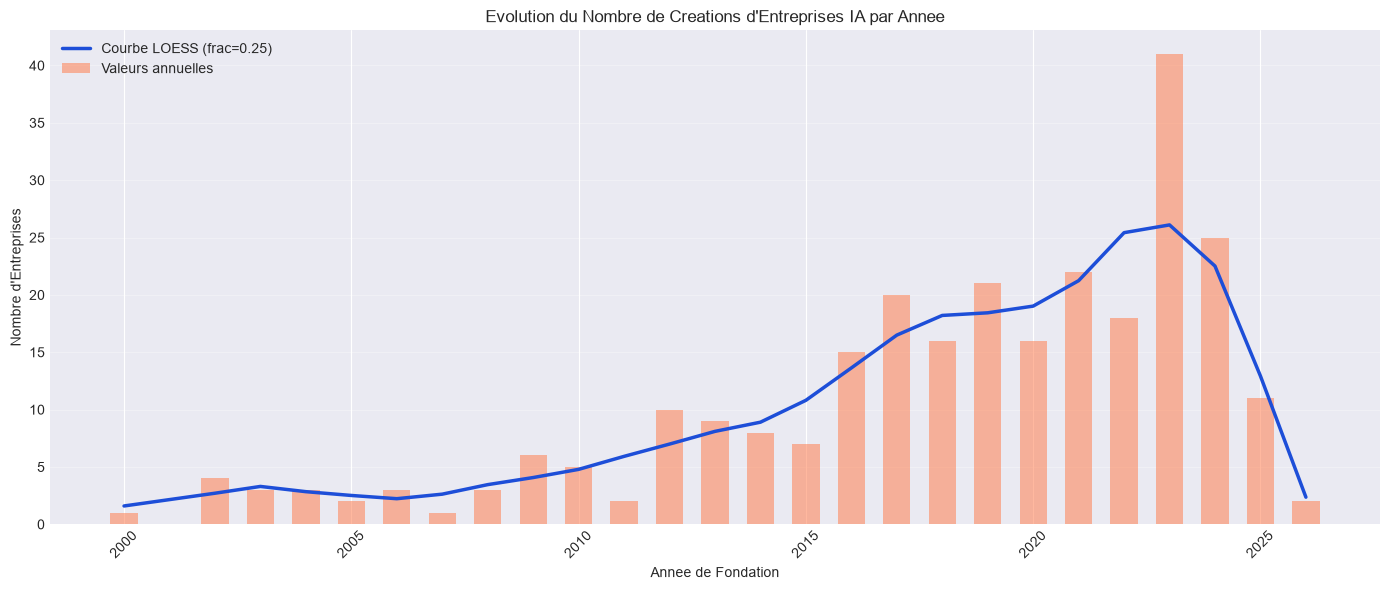

In [ ]:
# Visualiser la dynamique annuelle avec courbe LOESS
if "year_counts" not in globals() or year_counts.empty:
    print("⚠ Pas de donnees annuelles a visualiser.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    # A partir de 2000
    year_counts_plot = year_counts[year_counts.index >= 2000]

    if year_counts_plot.empty:
        print("⚠ Pas de donnees depuis 2000 pour le graphique annuel.")
    else:
        ax.bar(
            year_counts_plot.index,
            year_counts_plot.values,
            color="coral",
            width=0.6,
            alpha=0.55,
            label="Valeurs annuelles",
        )
        ax.set_xlabel("Annee de Fondation")
        ax.set_ylabel("Nombre d'Entreprises")
        ax.set_title("Evolution du Nombre de Creations d'Entreprises IA par Annee")
        ax.grid(axis="y", alpha=0.3)

        # Courbe LOESS (preset 1: plus fidele aux variations)
        if len(year_counts_plot) >= 3:
            try:
                from statsmodels.nonparametric.smoothers_lowess import lowess

                loess_frac = 0.2
                loess_fit = lowess(
                    endog=year_counts_plot.values,
                    exog=year_counts_plot.index.values,
                    frac=loess_frac,
                    it=0,
                    return_sorted=True,
                )

                ax.plot(
                    loess_fit[:, 0],
                    loess_fit[:, 1],
                    color="#1D4ED8",
                    linewidth=2.5,
                    label=f"Courbe LOESS (frac={loess_frac})",
                )
                ax.legend()
            except ImportError:
                print("⚠ statsmodels non installe: courbe LOESS non tracee.")
            except Exception as e:
                print(f"⚠ Echec du lissage LOESS: {e}")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

**Lecture rapide**: interpretation a relativiser selon la part de fiches avec annee renseignee.

## 5. Analyse croisee pays x annee

**Objectif**: comparer les rythmes de creation selon les principaux pays.

**Sorties**: tableau croise, heatmap et aire empilee sur la periode recente.

In [39]:
# Creer un tableau croise dynamique
pivot = pd.DataFrame()

required_cols = {"id", "country", "founded_year"}
if df is None or df.empty or not required_cols.issubset(df.columns):
    print("⚠ Donnees insuffisantes pour l'analyse croisee pays x annee.")
else:
    df_analysis = df.copy()
    df_analysis["country"] = df_analysis["country"].fillna("Unknown").astype(str).str.strip()
    df_analysis["country"] = df_analysis["country"].replace("", "Unknown")
    df_analysis["founded_year"] = pd.to_numeric(df_analysis["founded_year"], errors="coerce")
    df_analysis = df_analysis[df_analysis["founded_year"].notna()].copy()
    df_analysis["founded_year"] = df_analysis["founded_year"].astype(int)

    if df_analysis.empty:
        print("⚠ Aucune donnee annee/pays exploitable pour le croise.")
    else:
        # Top 8 pays pour plus de clarte
        top_8_countries = df_analysis["country"].value_counts().head(8).index
        df_top8 = df_analysis[df_analysis["country"].isin(top_8_countries)]

        # Creer un pivot table
        pivot = df_top8.pivot_table(
            values="id",
            index="founded_year",
            columns="country",
            aggfunc="count",
            fill_value=0,
        )

        print("\n📊 Tableau Croise - Top 8 Pays par Annee:\n")
        print(pivot.tail(15))


📊 Tableau Croise - Top 8 Pays par Annee:

country       China  France  Germany  Netherlands  Spain  Sweden  \
founded_year                                                       
2012              2       0        1            0      0       0   
2013              1       1        0            1      1       0   
2014              3       2        1            1      0       0   
2015              2       0        1            0      0       0   
2016              0       3        1            1      0       0   
2017              0       2        4            3      0       0   
2018              0       1        1            1      0       0   
2019              0       4        6            3      0       0   
2020              0       2        6            0      0       1   
2021              1       0        5            5      0       0   
2022              0       1        3            0      0       2   
2023              5       8        6            1      0       1   
2024 

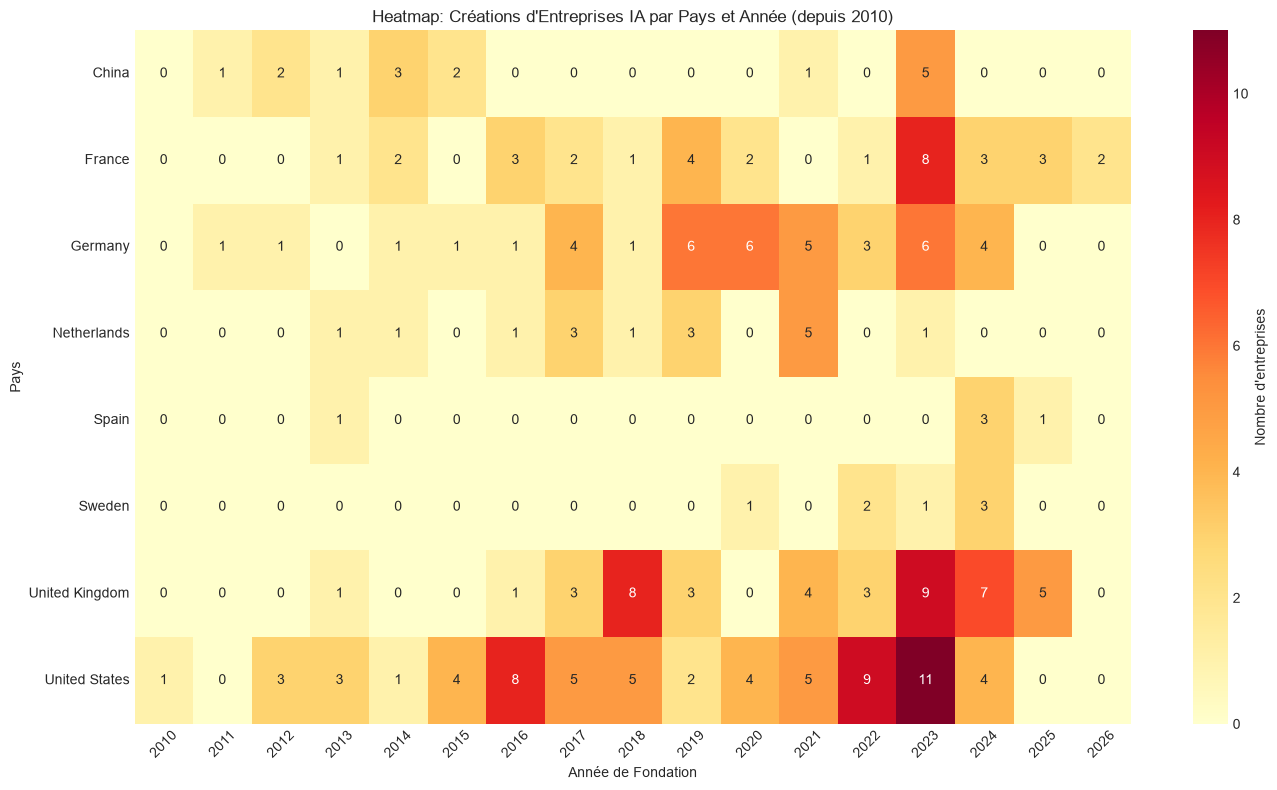

In [40]:
# Visualiser le tableau croisé avec un heatmap
if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    pivot_recent = pivot[pivot.index >= 2010]  # À partir de 2010
    
    if len(pivot_recent) > 0:
        sns.heatmap(pivot_recent.T, annot=True, fmt='d', cmap='YlOrRd', 
                    cbar_kws={'label': 'Nombre d\'entreprises'}, ax=ax)
        
        ax.set_xlabel('Année de Fondation')
        ax.set_ylabel('Pays')
        ax.set_title('Heatmap: Créations d\'Entreprises IA par Pays et Année (depuis 2010)')
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Pas de données depuis 2010 pour la heatmap")
else:
    print("⚠ Pas de données croisées disponibles")

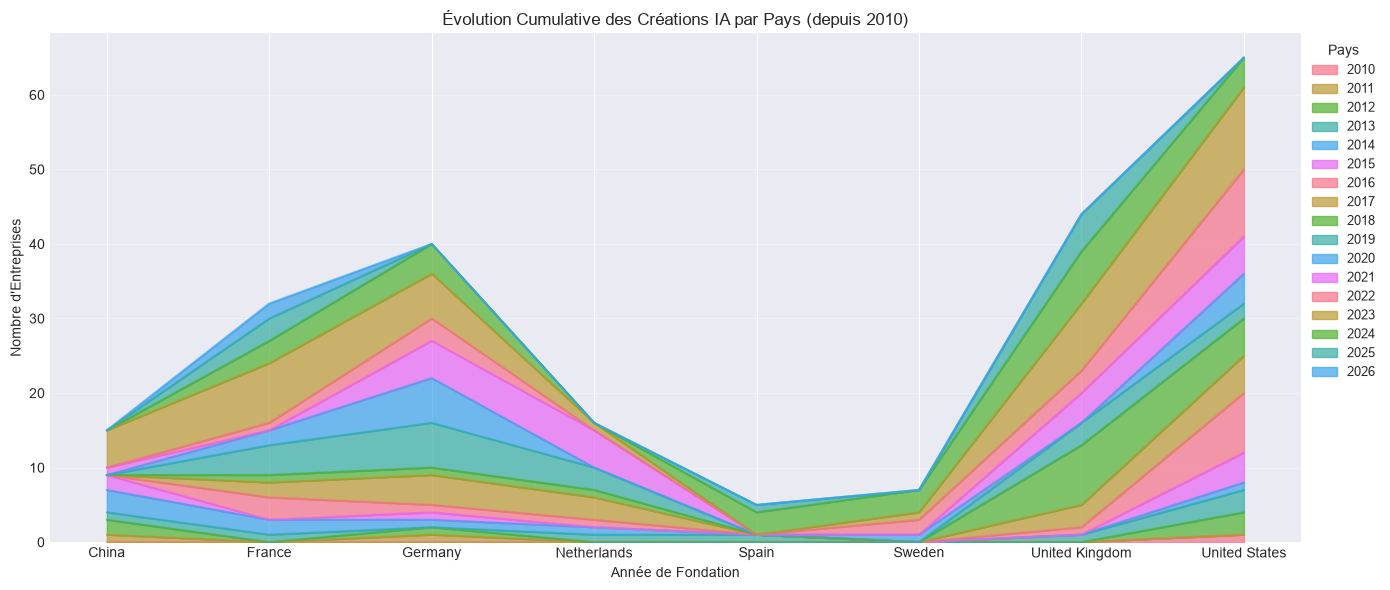

In [41]:
# Graphique en aire empilée
if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    pivot_recent = pivot[pivot.index >= 2010]
    
    if len(pivot_recent) > 0:
        pivot_recent_T = pivot_recent.T
        
        pivot_recent_T.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
        ax.set_xlabel('Année de Fondation')
        ax.set_ylabel('Nombre d\'Entreprises')
        ax.set_title('Évolution Cumulative des Créations IA par Pays (depuis 2010)')
        ax.legend(title='Pays', loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Pas de données depuis 2010 pour le graphique")
else:
    print("⚠ Pas de données croisées disponibles")

**Lecture rapide**: cette section distingue les pays en acceleration recente de ceux en trajectoire stable.

## 6. Analyse par secteur

**Objectif**: identifier les domaines IA les plus representes.

**Sorties**: distribution sectorielle complete et focus top 20 secteurs.


🔧 Repartition par Secteur (226 secteurs):

sector
ICT                                        417
Unknown                                    288
ICT, Manufacturing & Operations            160
AI model                                    70
Manufacturing & Operations                  69
                                          ... 
AI model, Computer Vision                    1
Biotech, Health & Social Care, Oncology      1
Health & Social Care, AI model               1
Computer Vision, AI model                    1
Robotics, AI model                           1
Name: count, Length: 226, dtype: int64


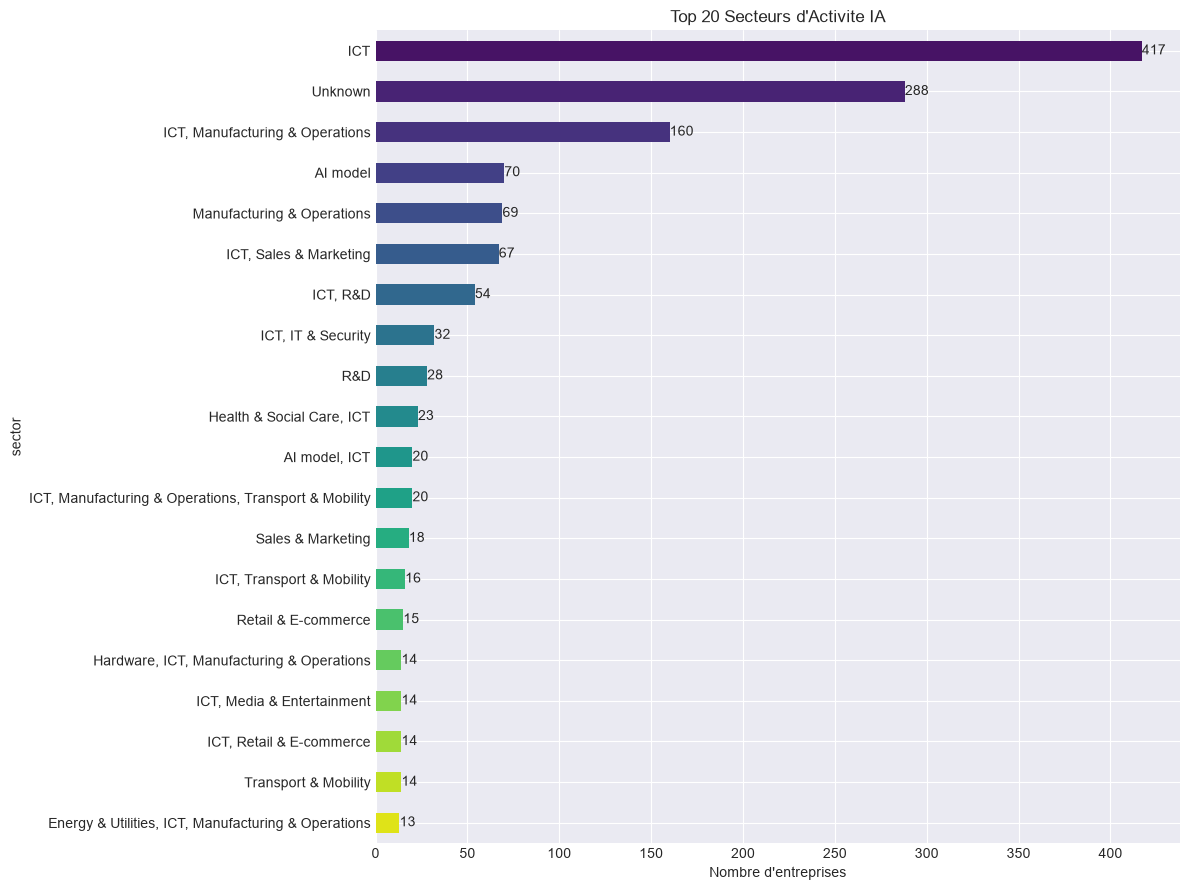

In [42]:
# Secteurs
if df is None or df.empty or "sector" not in df.columns:
    print("⚠ Aucune donnee secteur disponible.")
else:
    sector_counts = (
        df["sector"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
        .value_counts()
    )

    print(f"\n🔧 Repartition par Secteur ({len(sector_counts)} secteurs):\n")
    print(sector_counts)

    # Top 20 secteurs
    top_sectors = sector_counts.head(20)

    if top_sectors.empty:
        print("⚠ Aucun secteur exploitable a visualiser.")
    else:
        fig, ax = plt.subplots(figsize=(12, 9))
        palette = sns.color_palette("viridis", len(top_sectors))
        top_sectors.plot(kind="barh", ax=ax, color=palette)
        ax.set_xlabel("Nombre d'entreprises")
        ax.set_title("Top 20 Secteurs d'Activite IA")
        ax.invert_yaxis()

        # Ajouter les chiffres
        for i, v in enumerate(top_sectors.values):
            ax.text(v + 0.1, i, str(v), va="center")

        plt.tight_layout()
        plt.show()

**Lecture rapide**: le classement sectoriel sert a prioriser la normalisation des libelles et l'enrichissement cible.

## 7. Synthese et insights

**Objectif**: consolider les KPI clefs pour orienter les prochains chantiers data.

**Axes resumes**: volume, geographie, temporalite, validation, completude, finance.

In [43]:
# Resume statistique complet (cellule autonome)
if df is None or df.empty:
    print("\n" + "=" * 60)
    print("SYNTHESE - RESEAUX D'ACTEURS IA")
    print("=" * 60)
    print("\n⚠ Aucune donnee disponible.")
    print("=" * 60)
else:
    country_series = (
        df["country"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
        if "country" in df.columns else pd.Series(["Unknown"] * len(df))
    )
    sector_series = (
        df["sector"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
        if "sector" in df.columns else pd.Series(["Unknown"] * len(df))
    )

    country_counts_local = country_series.value_counts()
    sector_counts_local = sector_series.value_counts()

    df_year_local = pd.DataFrame()
    if "founded_year" in df.columns:
        year_num = pd.to_numeric(df["founded_year"], errors="coerce")
        df_year_local = df[year_num.notna()].copy()
        if not df_year_local.empty:
            df_year_local["founded_year"] = year_num[year_num.notna()].astype(int)

    print("\n" + "=" * 60)
    print("SYNTHESE - RESEAUX D'ACTEURS IA")
    print("=" * 60)

    print("\n📊 GLOBAL")
    print(f"  Total d'entreprises: {len(df)}")
    print(f"  Nombre de pays: {country_counts_local.index.nunique()}")
    print(f"  Nombre de secteurs: {sector_counts_local.index.nunique()}")
    if not df_year_local.empty:
        print(f"  Periode couverte: {df_year_local['founded_year'].min():.0f} - {df_year_local['founded_year'].max():.0f}")
    else:
        print("  Periode couverte: non disponible")

    print("\n🌍 TOP PAYS")
    for i, (country, count) in enumerate(country_counts_local.head(5).items(), 1):
        pct = (count / len(df)) * 100
        print(f"  {i}. {country:15s}: {count:3d} entreprises ({pct:5.1f}%)")

    print("\n📅 ANALYSE TEMPORELLE")
    if not df_year_local.empty:
        print(f"  Annee moyenne de creation: {df_year_local['founded_year'].mean():.1f}")
        print(f"  Mediane: {df_year_local['founded_year'].median():.0f}")
        print(f"  Ecart-type: {df_year_local['founded_year'].std():.1f}")
        recent_years = df_year_local[df_year_local["founded_year"] >= 2020]
        pct_recent = (len(recent_years) / len(df_year_local) * 100) if len(df_year_local) else 0
        print(f"  Creations depuis 2020: {len(recent_years)} ({pct_recent:.1f}% du total avec annee)")
    else:
        print("  Donnees temporelles insuffisantes")

    print("\n🔧 TOP SECTEURS")
    for i, (sector, count) in enumerate(sector_counts_local.head(5).items(), 1):
        pct = (count / len(df)) * 100
        print(f"  {i}. {sector:25s}: {count:3d} entreprises ({pct:5.1f}%)")

    print("\n💰 CAPITALISATION (format en millions)")
    if "capitalization_millions" in df.columns:
        cap_vals = pd.to_numeric(df["capitalization_millions"], errors="coerce").fillna(0)
        cap_known = (cap_vals > 0).sum()
        print(f"  Fiches avec capitalisation renseignee (>0): {cap_known} ({(cap_known/len(df)*100):.1f}%)")
        print(f"  Somme des capitalisations (M): {cap_vals.sum():,.1f}".replace(',', ' '))
        print(f"  Mediane (M): {cap_vals.median():,.1f}".replace(',', ' '))
    else:
        print("  Capitalisation indisponible")

    print("\n✅ VALIDATION (3 niveaux)")
    if "is_validated" in df.columns:
        val = pd.to_numeric(df["is_validated"], errors="coerce").fillna(0).astype(int)
        non_validees = (val == 0).sum()
        partiellement_validees = (val == 1).sum()
        validees = (val == 2).sum()
        print(f"  Fiches non validees: {non_validees} ({(non_validees/len(df)*100):.1f}%)")
        print(f"  Fiches validees partiellement: {partiellement_validees} ({(partiellement_validees/len(df)*100):.1f}%)")
        print(f"  Fiches validees: {validees} ({(validees/len(df)*100):.1f}%)")
    else:
        print("  Statut de validation indisponible")

    print("\n📈 COMPLETUDE")
    desc_count = (df["description"].notna() & (df["description"].astype(str).str.strip() != "")).sum() if "description" in df.columns else 0
    web_count = (df["website"].notna() & (df["website"].astype(str).str.strip() != "")).sum() if "website" in df.columns else 0
    cap_info_count = (pd.to_numeric(df["capitalization_millions"], errors="coerce").fillna(0) > 0).sum() if "capitalization_millions" in df.columns else 0
    print(f"  Fiches avec description: {desc_count} ({(desc_count/len(df)*100):.1f}%)")
    print(f"  Fiches avec website: {web_count} ({(web_count/len(df)*100):.1f}%)")
    print(f"  Fiches avec capitalization (>0): {cap_info_count} ({(cap_info_count/len(df)*100):.1f}%)")

    print("\n" + "=" * 60)


SYNTHESE - RESEAUX D'ACTEURS IA

📊 GLOBAL
  Total d'entreprises: 1846
  Nombre de pays: 36
  Nombre de secteurs: 226
  Periode couverte: 1961 - 2026

🌍 TOP PAYS
  1. Germany        : 929 entreprises ( 50.3%)
  2. Sweden         : 213 entreprises ( 11.5%)
  3. Netherlands    : 174 entreprises (  9.4%)
  4. United States  : 169 entreprises (  9.2%)
  5. Unknown        : 160 entreprises (  8.7%)

📅 ANALYSE TEMPORELLE
  Annee moyenne de creation: 2015.4
  Mediane: 2019
  Ecart-type: 11.0
  Creations depuis 2020: 135 (44.9% du total avec annee)

🔧 TOP SECTEURS
  1. ICT                      : 417 entreprises ( 22.6%)
  2. Unknown                  : 288 entreprises ( 15.6%)
  3. ICT, Manufacturing & Operations: 160 entreprises (  8.7%)
  4. AI model                 :  70 entreprises (  3.8%)
  5. Manufacturing & Operations:  69 entreprises (  3.7%)

💰 CAPITALISATION (format en millions)
  Fiches avec capitalisation renseignee (>0): 242 (13.1%)
  Somme des capitalisations (M): 39 372 716.7
  

**Lecture rapide**: la synthese confirme une base large, mais encore inegale sur validation et donnees financieres.

## 8. Export des resultats

**Objectif**: transformer les analyses en jeux CSV reutilisables.

**Fichiers attendus**:
- `statistiques_par_pays.csv`;
- `statistiques_par_secteur.csv`;
- `donnees_completes.csv`.

In [44]:
# Exporter les statistiques cles en CSV
# Creer le dossier d'export s'il n'existe pas
export_dir = "./exports"
os.makedirs(export_dir, exist_ok=True)

try:
    if df is None or df.empty:
        print("⚠ Aucune donnee a exporter.")
    else:
        # Normalisation defensive des colonnes critiques
        required_defaults = {
            "id": None,
            "name": None,
            "sector": "Unknown",
            "country": "Unknown",
            "founded_year": np.nan,
            "is_validated": 0,
            "capitalization_millions": 0.0,
            "description": None,
            "website": None,
            "headquarter_city": None,
            "main_investors": None,
            "funds_raised": None,
            "capitalization": None,
        }
        for col, default in required_defaults.items():
            if col not in df.columns:
                df[col] = default

        df["is_validated"] = pd.to_numeric(df["is_validated"], errors="coerce").fillna(0).astype(int)
        df["capitalization_millions"] = pd.to_numeric(df["capitalization_millions"], errors="coerce").fillna(0.0)

        df["country"] = df["country"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")
        df["sector"] = df["sector"].fillna("Unknown").astype(str).str.strip().replace("", "Unknown")

        # Export 1: Resume par pays
        country_summary = df.groupby("country", dropna=False).agg(
            nombre_entreprises=("id", "count"),
            annee_creation_min=("founded_year", "min"),
            annee_creation_max=("founded_year", "max"),
            annee_creation_moyenne=("founded_year", "mean"),
            capitalisation_millions_totale=("capitalization_millions", "sum"),
            capitalisation_millions_moyenne=("capitalization_millions", "mean"),
            nombre_non_validees=("is_validated", lambda s: (s == 0).sum()),
            nombre_validees_partiellement=("is_validated", lambda s: (s == 1).sum()),
            nombre_validees=("is_validated", lambda s: (s == 2).sum()),
        ).round(1)
        country_summary["taux_validees_partiellement_pct"] = (
            country_summary["nombre_validees_partiellement"] / country_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        country_summary["taux_validees_pct"] = (
            country_summary["nombre_validees"] / country_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        country_summary = country_summary.sort_values("nombre_entreprises", ascending=False)
        country_summary.to_csv(f"{export_dir}/statistiques_par_pays.csv")
        print("✓ Exporte: statistiques_par_pays.csv")

        # Export 2: Resume par secteur
        sector_summary = df.groupby("sector", dropna=False).agg(
            nombre_entreprises=("id", "count"),
            annee_creation_min=("founded_year", "min"),
            annee_creation_max=("founded_year", "max"),
            annee_creation_moyenne=("founded_year", "mean"),
            capitalisation_millions_totale=("capitalization_millions", "sum"),
            capitalisation_millions_moyenne=("capitalization_millions", "mean"),
            nombre_non_validees=("is_validated", lambda s: (s == 0).sum()),
            nombre_validees_partiellement=("is_validated", lambda s: (s == 1).sum()),
            nombre_validees=("is_validated", lambda s: (s == 2).sum()),
        ).round(1)
        sector_summary["taux_validees_partiellement_pct"] = (
            sector_summary["nombre_validees_partiellement"] / sector_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        sector_summary["taux_validees_pct"] = (
            sector_summary["nombre_validees"] / sector_summary["nombre_entreprises"].replace(0, np.nan) * 100
        ).fillna(0).round(1)
        sector_summary = sector_summary.sort_values("nombre_entreprises", ascending=False)
        sector_summary.to_csv(f"{export_dir}/statistiques_par_secteur.csv")
        print("✓ Exporte: statistiques_par_secteur.csv")

        # Export 3: Donnees brutes enrichies
        export_cols = [
            "id", "name", "sector", "country", "founded_year",
            "is_validated", "description", "website",
            "capitalization", "capitalization_millions",
            "headquarter_city", "main_investors", "funds_raised",
        ]
        export_cols = [c for c in export_cols if c in df.columns]
        df_export = df[export_cols].copy()
        df_export.to_csv(f"{export_dir}/donnees_completes.csv", index=False)
        print("✓ Exporte: donnees_completes.csv")

        print(f"\n✓ Tous les exports disponibles dans: {export_dir}/")
except Exception as e:
    print(f"✗ Erreur lors de l'export: {e}")

✓ Exporte: statistiques_par_pays.csv
✓ Exporte: statistiques_par_secteur.csv
✓ Exporte: donnees_completes.csv

✓ Tous les exports disponibles dans: ./exports/


**Lecture rapide**: ces exports servent de base de restitution et de suivi longitudinal des KPI.